In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.maxcut import MaxCut
from src.simulator import QuimbSimulator
from src.optimizer import COBYLA, SMO
from src.lvqe import LayerVQE
from collections import Counter

In [2]:
SEED=562

SIMULATOR=SMO

num_nodes = 32
def get_random_graph(N: int, seed: int = SEED, plot=False):
    assert N % 2 == 0
    while True:
        G = nx.random_regular_graph(3, num_nodes)
        if nx.is_connected(G):
            if plot:
                plt.figure(figsize=(8, 6))
                pos = nx.spring_layout(G, seed=seed)
                nx.draw(G, pos, with_labels=True, node_color='lightblue',
                    node_size=400, font_size=10, font_weight='bold')
                plt.title(f"Random regular graph G(k=3, N={G.number_of_nodes()}): {G.number_of_edges()} edges")
                plt.show()
            return G
        else:
            seed += 1
    return None

G = get_random_graph(num_nodes, seed=SEED, plot=False)

np.random.seed(SEED)

In [3]:
problem = MaxCut(G, seed=SEED)
print(f"\nn_qubits: {problem.num_qubits}")
print(f"n_terms: {len(problem.hamiltonian_terms)}\n")

sim = QuimbSimulator()

best_known = problem.best_known_value

print(f"best known cut value : {best_known}")
print(f"corresponding energy: {problem.cut_to_energy(best_known)}")



n_qubits: 31
n_terms: 48

best known cut value : 44.0
corresponding energy: -20.0


Starting L-VQE: 1 layers, 100 iter/layer, 300 final iter
Mode: exact expectation

Layer 0: 

layer 0: energy=-14.0000, approx_ratio=+0.8636

Final layer — 300 iterations (final)
layer 1: energy=-14.0000, approx_ratio=+0.8636

Final approximation ratio: 0.8636


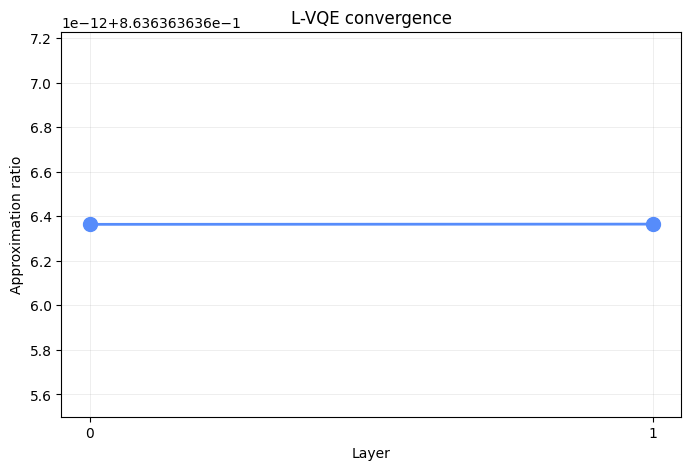

In [4]:
# run L-VQE
lvqe = LayerVQE(
    problem=problem,
    simulator=sim,
    optimizer_class=SIMULATOR,
    n_layers=1,
    k_per_layer=100,
    k_final=300,
    use_sampling=False
)

result = lvqe.run()

print(f"\nFinal approximation ratio: {result['final_approx_ratio']:.4f}")

# plot the convergence
plt.figure(figsize=(8, 5))
plt.plot(result['history']['layer'], result['history']['approx_ratio'],
         'o-', linewidth=2, markersize=10)
plt.xlabel('Layer')
plt.ylabel('Approximation ratio')
plt.title('L-VQE convergence')
plt.grid(True, alpha=0.3)
plt.xticks(result['history']['layer'])
plt.show()

In [5]:
bitstrings = sim.get_most_frequent_assignments(result['final_params'], result['final_ansatz'], problem=problem)

for (assignment, proba) in bitstrings:
    print(f"Assignment {assignment} (proba: {proba})")
    cut_value = problem.evaluate(assignment)
    print(f"Corresponding cut value: {cut_value}")
    print(f"Corresponding energy: {problem.cut_to_energy(cut_value)}")

Assignment [0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0] (proba: 100.0)
Corresponding cut value: 38.0
Corresponding energy: -14.0
